In [21]:
%pip install seaborn scikit-learn Jinja2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Algorithmes de clustering
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

# Métriques et prétraitement
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

# Configuration esthétique pour les graphiques
%matplotlib inline
sns.set_theme(style="whitegrid")

In [22]:
import os

# Remplace 'ton_fichier.csv' par le nom réel de ton fichier
file_path = 'Titanic-Dataset.csv' 

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print(f"✅ Fichier '{file_path}' chargé avec succès.")
    
    # Affichage des infos de base
    print("\n--- Infos du Dataset ---")
    df.info()
    
    # Visualisation des premières lignes
    display(df.head())
else:
    print(f"❌ Erreur : Le fichier '{file_path}' est introuvable dans le répertoire actuel.")
    print("Répertoire actuel :", os.getcwd())

✅ Fichier 'Titanic-Dataset.csv' chargé avec succès.

--- Infos du Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 66.2+ KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# =========================================================
# 1. PARAMÈTRES GLOBAUX
# =========================================================
# Pas de TARGET_COLUMN ici car nous sommes en non supervisé
SEUIL_CARDINALITE = 0.50  
SEUIL_SUPPRESSION = 40.0  
SEUIL_SKEWNESS = 1.0     

# =========================================================
# 2. NETTOYAGE ET DÉTECTION DES IDENTIFIANTS
# =========================================================
def preparer_donnees_clustering(df_input: pd.DataFrame) -> pd.DataFrame:
    df_proc = df_input.copy()
    cols_to_drop = []
    
    for col in df_proc.columns:
        # 1. Cardinalité (Détection d'IDs)
        cardinality = df_proc[col].nunique() / len(df_proc)
        if cardinality > SEUIL_CARDINALITE:
            cols_to_drop.append(col)
            print(f"❌ [DROP] '{col}' | Cardinalité: {cardinality:.2f} (ID potentiel)")
            continue
            
        # 2. Suppression si trop de vides
        missing_pct = df_proc[col].isnull().mean() * 100
        if missing_pct > SEUIL_SUPPRESSION:
            cols_to_drop.append(col)
            print(f"❌ [DROP] '{col}' | {missing_pct:.1f}% manquants")
            
    return df_proc.drop(columns=cols_to_drop)

df_clean = preparer_donnees_clustering(df)

# =========================================================
# 3. IMPUTATION CIBLÉE (SUR L'ENSEMBLE DU DATASET)
# =========================================================
print("\n🔍 PHASE D'IMPUTATION...")

for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        if pd.api.types.is_numeric_dtype(df_clean[col]):
            skew = df_clean[col].skew()
            # Choix mean/median
            strat = 'median' if abs(skew) > SEUIL_SKEWNESS else 'mean'
            print(f"📊 '{col}' | Skew: {skew:.2f} → Imputation: {strat.upper()}")
        else:
            strat = 'most_frequent'
            print(f"📊 '{col}' | Catégorielle → Imputation: MODE")
            
        imp = SimpleImputer(strategy=strat)
        df_clean[[col]] = imp.fit_transform(df_clean[[col]])

# =========================================================
# 4. ENCODAGE ET NORMALISATION
# =========================================================
# Encodage pour transformer les catégories restantes en numérique
df_final = pd.get_dummies(df_clean, drop_first=True)

print(f"\n📏 NORMALISATION...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_final)

print(f"✅ PIPELINE PRÊT : {X_scaled.shape[0]} lignes, {X_scaled.shape[1]} features.")

❌ [DROP] 'PassengerId' | Cardinalité: 1.00 (ID potentiel)
❌ [DROP] 'Name' | Cardinalité: 1.00 (ID potentiel)
❌ [DROP] 'Ticket' | Cardinalité: 0.76 (ID potentiel)
❌ [DROP] 'Cabin' | 77.1% manquants

🔍 PHASE D'IMPUTATION...
📊 'Age' | Skew: 0.39 → Imputation: MEAN
📊 'Embarked' | Catégorielle → Imputation: MODE

📏 NORMALISATION...
✅ PIPELINE PRÊT : 891 lignes, 9 features.


📊 Comparatif des métriques de performance :


,K (Clusters),Inertie (Elbow),Silhouette Score,Calinski-Harabasz
0,2,6597.990,0.254,191.464
1,3,5493.163,0.301,204.158
2,4,4655.799,0.317,213.580
3,5,4101.739,0.300,211.538
4,6,3684.525,0.295,208.223
5,7,3416.477,0.291,198.481
6,8,3172.486,0.295,192.705
7,9,2984.843,0.313,185.945
8,10,2808.182,0.319,181.641


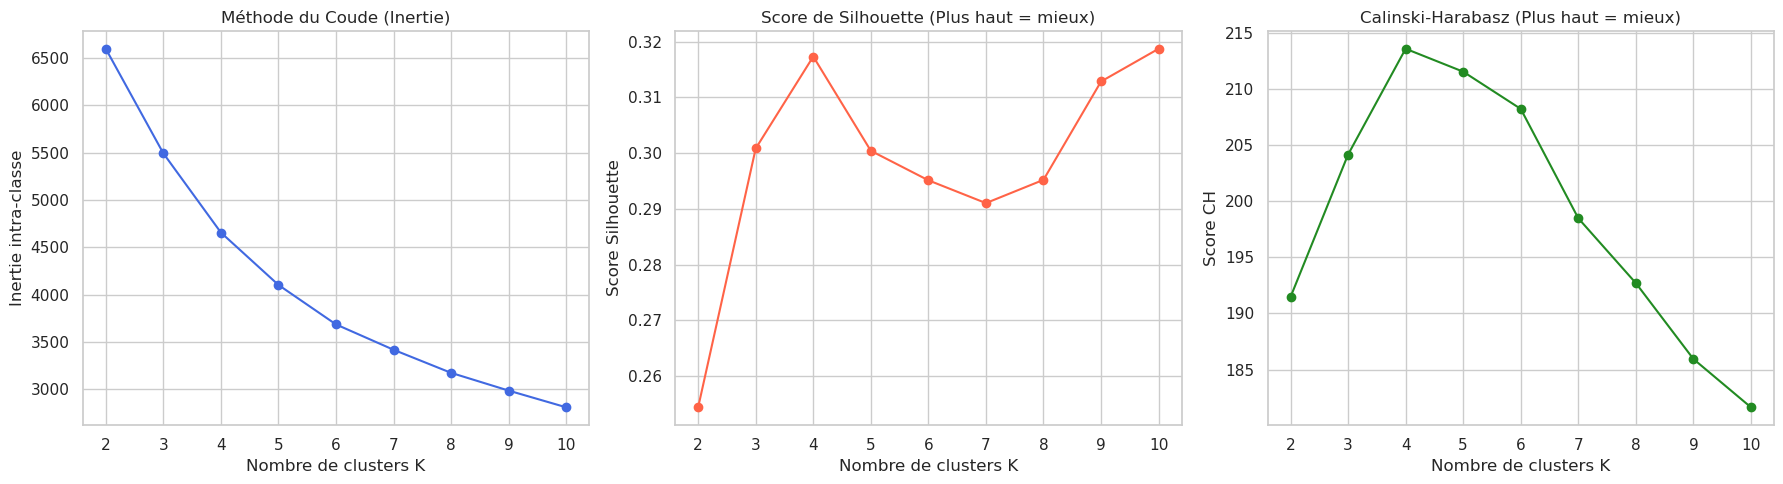

--- 💡 PROPOSITIONS DE K ---
👉 Selon le Coude : K = 4
   Justification : C'est le point d'inflexion où l'ajout d'un cluster n'apporte plus 
   de gain d'inertie significatif (compromis complexité/précision).

👉 Selon Silhouette : K = 10
   Justification : C'est ici que la séparation entre les groupes est la plus nette 
   et que les points sont les mieux affectés à leur propre cluster (Score max: 0.319).

👉 Selon Calinski-Harabasz : K = 4
   Justification : Ce K maximise le ratio entre la dispersion inter-clusters 
   et la dispersion intra-cluster (modèle le plus dense et dispersé).

🚀 RECOMMANDATION GLOBALE : K = 4


In [24]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score

# =========================================================
# CALCUL DES MÉTRIQUES POUR DIFFÉRENTS K
# =========================================================
range_n_clusters = range(2, 11)  # On teste de 2 à 10 clusters
inertias = []
silhouette_avg = []
calinski_scores = []

for k in range_n_clusters:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouette_avg.append(silhouette_score(X_scaled, labels))
    calinski_scores.append(calinski_harabasz_score(X_scaled, labels))

# =========================================================
# TABLEAU RÉCAPITULATIF
# =========================================================
df_metrics = pd.DataFrame({
    'K (Clusters)': range_n_clusters,
    'Inertie (Elbow)': inertias,
    'Silhouette Score': silhouette_avg,
    'Calinski-Harabasz': calinski_scores
})

print("📊 Comparatif des métriques de performance :")
display(df_metrics.round(3))

# =========================================================
# VISUALISATION DES GRAPHES
# =========================================================
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# 1. Méthode du Coude (Inertie)
ax[0].plot(range_n_clusters, inertias, marker='o', color='royalblue')
ax[0].set_title('Méthode du Coude (Inertie)')
ax[0].set_xlabel('Nombre de clusters K')
ax[0].set_ylabel('Inertie intra-classe')

# 2. Score de Silhouette
ax[1].plot(range_n_clusters, silhouette_avg, marker='o', color='tomato')
ax[1].set_title('Score de Silhouette (Plus haut = mieux)')
ax[1].set_xlabel('Nombre de clusters K')
ax[1].set_ylabel('Score Silhouette')

# 3. Indice Calinski-Harabasz
ax[2].plot(range_n_clusters, calinski_scores, marker='o', color='forestgreen')
ax[2].set_title('Calinski-Harabasz (Plus haut = mieux)')
ax[2].set_xlabel('Nombre de clusters K')
ax[2].set_ylabel('Score CH')

plt.tight_layout()
plt.show()

# =========================================================
# PROPOSITIONS AUTOMATIQUES ET JUSTIFICATIONS
# =========================================================

# 1. Détection du coude (Elbow) par la méthode de la dérivée seconde (accélération de la courbe)
# On cherche le point où la diminution de l'inertie ralentit le plus brutalement.
diffs = np.diff(inertias)
diffs_2 = np.diff(diffs)
k_elbow = range_n_clusters[np.argmax(diffs_2) + 1]

# 2. Détection du meilleur Silhouette Score (Maximum)
k_silhouette = df_metrics.loc[df_metrics['Silhouette Score'].idxmax(), 'K (Clusters)']

# 3. Détection du meilleur Calinski-Harabasz (Maximum)
k_calinski = df_metrics.loc[df_metrics['Calinski-Harabasz'].idxmax(), 'K (Clusters)']

print("--- 💡 PROPOSITIONS DE K ---")

print(f"👉 Selon le Coude : K = {k_elbow}")
print(f"   Justification : C'est le point d'inflexion où l'ajout d'un cluster n'apporte plus ")
print(f"   de gain d'inertie significatif (compromis complexité/précision).")

print(f"\n👉 Selon Silhouette : K = {k_silhouette}")
print(f"   Justification : C'est ici que la séparation entre les groupes est la plus nette ")
print(f"   et que les points sont les mieux affectés à leur propre cluster (Score max: {df_metrics['Silhouette Score'].max():.3f}).")

print(f"\n👉 Selon Calinski-Harabasz : K = {k_calinski}")
print(f"   Justification : Ce K maximise le ratio entre la dispersion inter-clusters ")
print(f"   et la dispersion intra-cluster (modèle le plus dense et dispersé).")

# Recommandation finale par vote majoritaire
suggestions = [k_elbow, k_silhouette, k_calinski]
k_final = max(set(suggestions), key=suggestions.count)

print(f"\n🚀 RECOMMANDATION GLOBALE : K = {k_final}")

✅ K-Means exécuté avec K = 4

📊 Répartition des points par cluster :


,Nombre de points
Cluster_KMeans,
0,461
1,127
2,76
3,227



📍 Centroïdes (Positions dans l'espace normalisé) :


,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,-0.601934,0.269244,0.125302,-0.291503,-0.398280,-0.335732,0.583311,-0.307562,0.304912
1,0.182190,0.375065,-0.972007,1.318699,1.823227,0.168895,-0.531452,-0.279539,0.298409
2,0.022410,0.717151,-0.055059,-0.080569,-0.343010,-0.385312,-0.226310,3.251373,-1.623803
3,1.112997,-0.996732,0.307777,-0.118805,-0.096361,0.716328,-0.811508,-0.307562,-0.242526



📝 Caractéristiques moyennes réelles par cluster :


,Survived,Pclass,Age,SibSp,Parch,Fare,Cluster_CAH,Cluster_DBSCAN
Cluster_KMeans,,,,,,,,
0,0.091106,2.533623,31.327377,0.201735,0.060738,15.529896,2.000000,-0.127983
1,0.472441,2.622047,17.068164,1.976378,1.850394,40.592454,1.811024,-1.000000
2,0.394737,2.907895,28.983642,0.434211,0.105263,13.067491,2.000000,-0.394737
3,0.925110,1.475771,33.698589,0.392070,0.303965,67.781041,1.986784,-1.000000


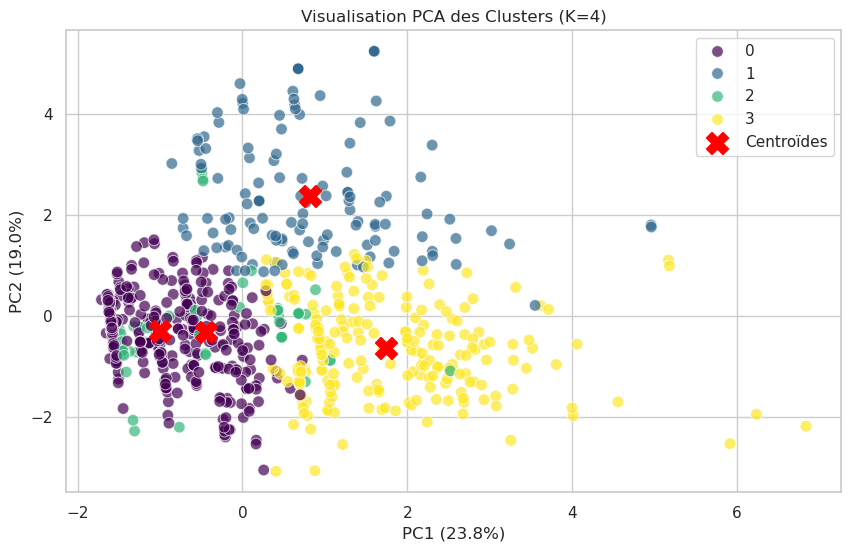

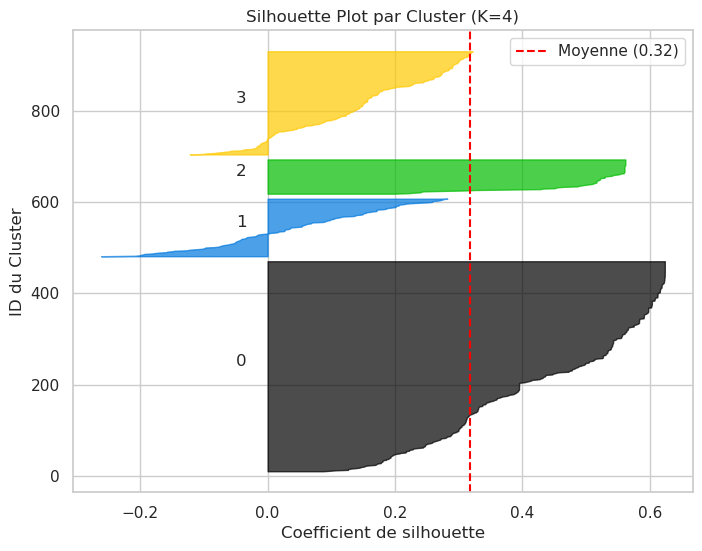

In [52]:
# =========================================================
# APPLICATION DU K-MEANS FINAL (NON SUPERVISÉ)
# =========================================================
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm

# 1. Configuration et Entraînement
# k_final est récupéré de ta cellule de décision automatique
model_kmeans = KMeans(n_clusters=k_final, init='k-means++', n_init=10, random_state=42)
clusters = model_kmeans.fit_predict(X_scaled)

# Ajout des labels au DataFrame de travail
df_clean['Cluster_KMeans'] = clusters

# ---------------------------------------------------------
# A. AFFICHAGE DES TAILLES ET CENTROÏDES
# ---------------------------------------------------------
print(f"✅ K-Means exécuté avec K = {k_final}")

# Taille de chaque cluster
cluster_counts = df_clean['Cluster_KMeans'].value_counts().sort_index()
print("\n📊 Répartition des points par cluster :")
display(cluster_counts.to_frame(name='Nombre de points'))

# Centroïdes (Coordonnées moyennes dans l'espace normalisé)
# On utilise df_final.columns qui correspond aux colonnes après get_dummies
centroids_scaled = pd.DataFrame(model_kmeans.cluster_centers_, columns=df_final.columns)
print("\n📍 Centroïdes (Positions dans l'espace normalisé) :")
display(centroids_scaled)

# Profil moyen (Valeurs réelles pour interprétation métier)
print("\n📝 Caractéristiques moyennes réelles par cluster :")
display(df_clean.groupby('Cluster_KMeans').mean(numeric_only=True))

# ---------------------------------------------------------
# B. VISUALISATION PCA (2D)
# ---------------------------------------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
centroids_pca = pca.transform(model_kmeans.cluster_centers_)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette='viridis', s=70, alpha=0.7)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker='X', s=250, color='red', label='Centroïdes')

plt.title(f"Visualisation PCA des Clusters (K={k_final})")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.legend()
plt.show()

# ---------------------------------------------------------
# C. ANALYSE DÉTAILLÉE DE LA SILHOUETTE
# ---------------------------------------------------------
def plot_silhouette_final(X, labels):
    n_clusters = len(np.unique(labels))
    fig, ax = plt.subplots(figsize=(8, 6))
    
    sample_silhouette_values = silhouette_samples(X, labels)
    y_lower = 10
    
    for i in range(n_clusters):
        ith_cluster_values = sample_silhouette_values[labels == i]
        ith_cluster_values.sort()
        
        size_cluster_i = ith_cluster_values.shape[0]
        y_upper = y_lower + size_cluster_i
        
        color = cm.nipy_spectral(float(i) / n_clusters)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_values,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    avg_score = silhouette_score(X, labels)
    ax.axvline(x=avg_score, color="red", linestyle="--", label=f"Moyenne ({avg_score:.2f})")
    ax.set_title(f"Silhouette Plot par Cluster (K={n_clusters})")
    ax.set_xlabel("Coefficient de silhouette")
    ax.set_ylabel("ID du Cluster")
    ax.legend()
    plt.show()

plot_silhouette_final(X_scaled, clusters)

📊 ANALYSE DE FIDÉLITÉ (Coefficient Cophénétique) :
   - Ward     : 0.6336
   - Complete : 0.7549
   - Average  : 0.8712
   - Single   : 0.7480

🚀 Recommandation : La méthode 'average' est la plus fidèle.


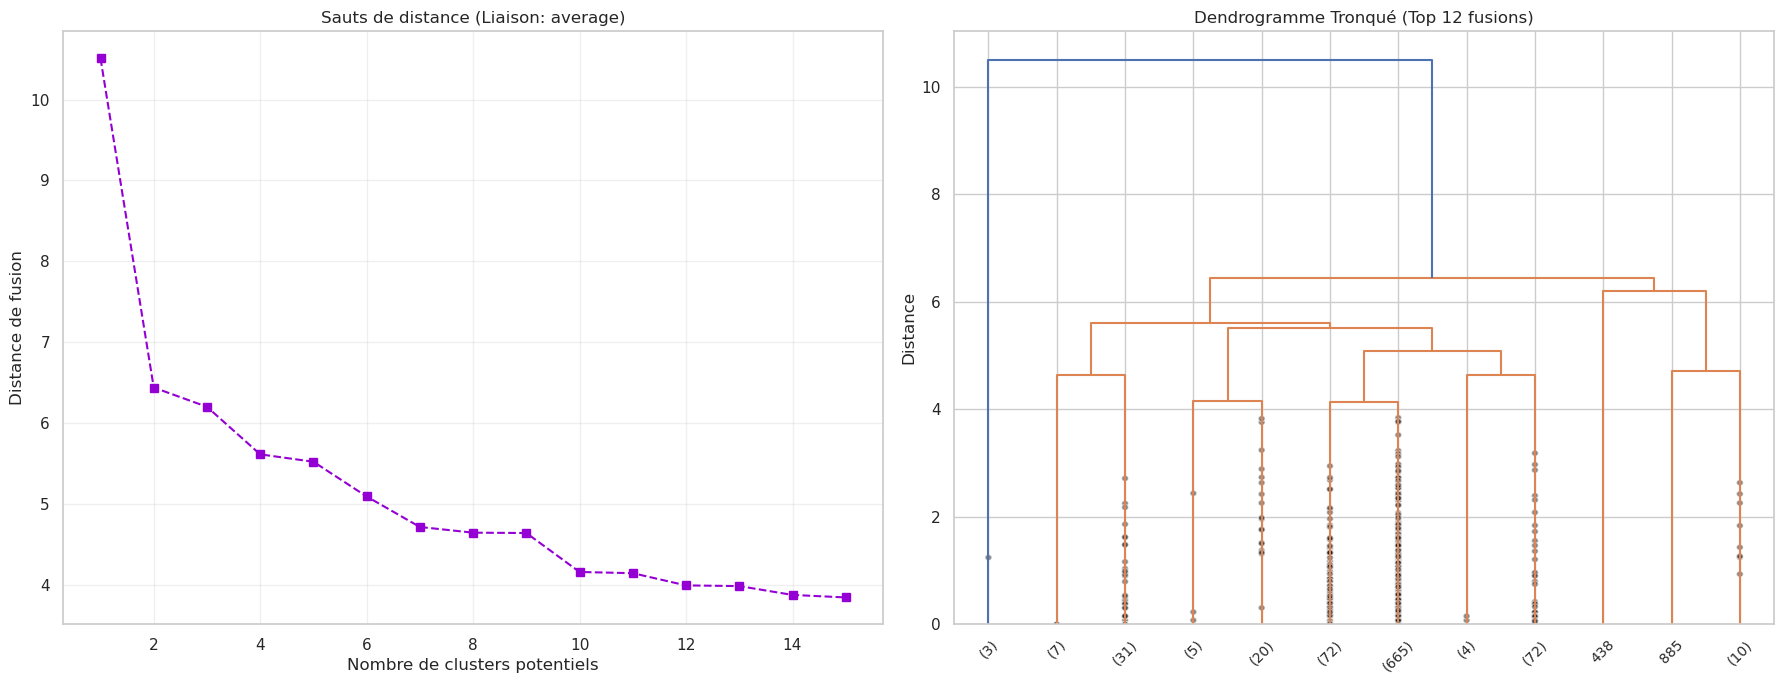

💡 DÉCISION :
Le saut de structure le plus net suggère K = 3
Justification : À ce stade, la fusion suivante regrouperait des groupes trop hétérogènes.


In [47]:
from scipy.cluster.hierarchy import linkage, dendrogram, cophenet
from scipy.spatial.distance import pdist
from sklearn.cluster import AgglomerativeClustering

# =========================================================
# 1. COMPARAISON DES MÉTHODES DE LIAISON (FIDÉLITÉ)
# =========================================================
dist_matrix = pdist(X_scaled)
methods = ['ward', 'complete', 'average', 'single']
coph_scores = {}

print("📊 ANALYSE DE FIDÉLITÉ (Coefficient Cophénétique) :")
for method in methods:
    # On calcule la liaison pour chaque méthode
    Z_temp = linkage(X_scaled, method=method)
    # Plus le score est proche de 1, mieux le dendrogramme reflète les distances réelles
    c, _ = cophenet(Z_temp, dist_matrix)
    coph_scores[method] = c
    print(f"   - {method.capitalize():<8} : {c:.4f}")

# Sélection automatique de la meilleure méthode (souvent 'ward' ou 'average')
best_method = max(coph_scores, key=coph_scores.get)
print(f"\n🚀 Recommandation : La méthode '{best_method}' est la plus fidèle.")

# =========================================================
# 2. CALCUL FINAL ET GRAPHES DE DÉCISION
# =========================================================
# On génère la matrice Z finale avec la meilleure méthode
Z = linkage(X_scaled, method=best_method)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# A. Graphique des distances de fusion (Recherche du saut/coude)
distances = Z[:, 2]
distances_rev = distances[::-1]
idxs = np.arange(1, len(distances_rev) + 1)

ax1.plot(idxs[:15], distances_rev[:15], marker='s', color='darkviolet', linestyle='--')
ax1.set_title(f"Sauts de distance (Liaison: {best_method})")
ax1.set_xlabel("Nombre de clusters potentiels")
ax1.set_ylabel("Distance de fusion")
ax1.grid(True, alpha=0.3)

# B. Dendrogramme tronqué pour lecture claire
dendrogram(
    Z, 
    truncate_mode='lastp', 
    p=12, 
    leaf_rotation=45., 
    leaf_font_size=10., 
    show_contracted=True,
    ax=ax2
)
ax2.set_title("Dendrogramme Tronqué (Top 12 fusions)")
ax2.set_ylabel("Distance")

plt.tight_layout()
plt.show()

# =========================================================
# 3. PROPOSITION AUTOMATIQUE DU K POUR CAH
# =========================================================
# On cherche l'accélération maximale (plus grand saut vertical dans l'arbre)
acceleration = np.diff(distances, 2)
k_cah_final = len(distances) - np.argmax(acceleration)

print(f"💡 DÉCISION :")
print(f"Le saut de structure le plus net suggère K = {k_cah_final}")
print(f"Justification : À ce stade, la fusion suivante regrouperait des groupes trop hétérogènes.")


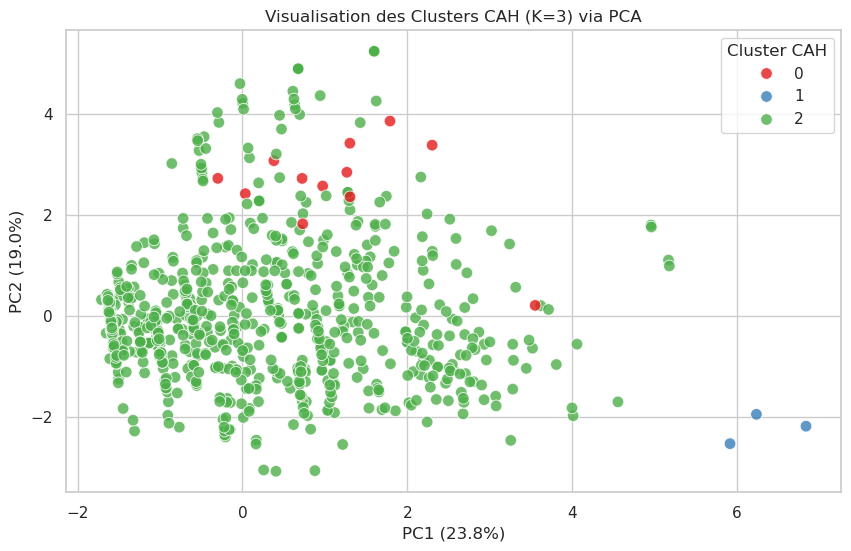

✅ Score de Silhouette Global (CAH) : 0.408

📊 Caractéristiques moyennes par cluster (CAH) :


,Survived,Pclass,Age,SibSp,Parch,Fare,Cluster_KMeans,Cluster_DBSCAN
Cluster_CAH,,,,,,,,
0,0.083333,2.833333,40.083333,0.750000,4.416667,51.522917,1.000000,-1.000000
1,1.000000,1.000000,35.333333,0.000000,0.333333,512.329200,3.000000,-1.000000
2,0.385845,2.305936,29.537573,0.521689,0.326484,30.295304,1.071918,-0.488584


In [53]:
# Application finale
cah_model = AgglomerativeClustering(n_clusters=k_cah_final, metric='euclidean', linkage=best_method) # <--- modifier au besoin
df_clean['Cluster_CAH'] = cah_model.fit_predict(X_scaled)
# =========================================================
# 1. VISUALISATION DES CLUSTERS CAH (PCA)
# =========================================================
pca_cah = PCA(n_components=2)
X_pca_cah = pca_cah.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_pca_cah[:, 0], y=X_pca_cah[:, 1], 
    hue=df_clean['Cluster_CAH'], palette='Set1', s=70, alpha=0.8
)
plt.title(f"Visualisation des Clusters CAH (K={k_cah_final}) via PCA")
plt.xlabel(f"PC1 ({pca_cah.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca_cah.explained_variance_ratio_[1]:.1%})")
plt.legend(title="Cluster CAH")
plt.show()

# =========================================================
# 2. VÉRIFICATION : SCORE DE SILHOUETTE ET PROFILAGE
# =========================================================
# Calcul du score de silhouette global pour la CAH
sil_cah = silhouette_score(X_scaled, df_clean['Cluster_CAH'])

print(f"✅ Score de Silhouette Global (CAH) : {sil_cah:.3f}")

# Profilage des clusters pour interprétation
cluster_profiles_cah = df_clean.groupby('Cluster_CAH').mean(numeric_only=True)
print("\n📊 Caractéristiques moyennes par cluster (CAH) :")
display(cluster_profiles_cah)

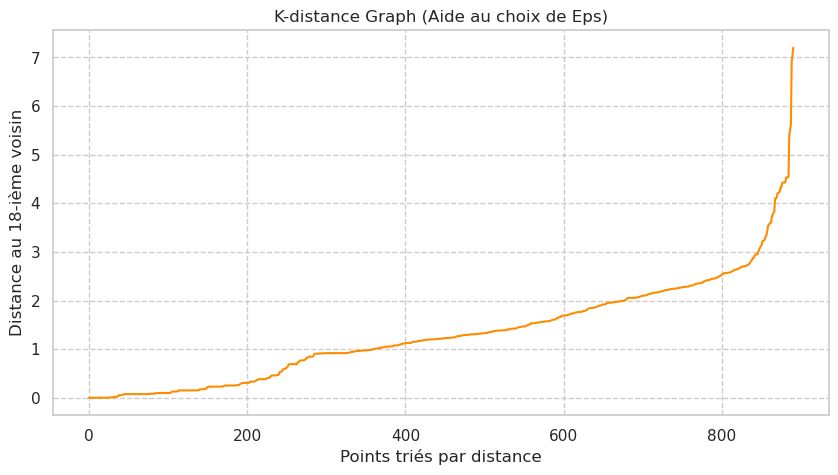

In [42]:
from sklearn.neighbors import NearestNeighbors

# On fixe k (min_samples). Une règle courante est 2 * nb_features
min_pts = X_scaled.shape[1] * 2

# Calcul des distances aux k plus proches voisins
neighbors = NearestNeighbors(n_neighbors=min_pts)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# On trie les distances du k-ième voisin (la dernière colonne)
s_distances = np.sort(distances[:, min_pts-1], axis=0)

# Visualisation
plt.figure(figsize=(10, 5))
plt.plot(s_distances, color='darkorange')
plt.title("K-distance Graph (Aide au choix de Eps)")
plt.xlabel("Points triés par distance")
plt.ylabel(f"Distance au {min_pts}-ième voisin")
plt.grid(True, linestyle='--')
plt.show()

✅ DBSCAN terminé
🔹 Nombre de clusters trouvés : 4
🔹 Nombre de points de bruit (outliers) : 639


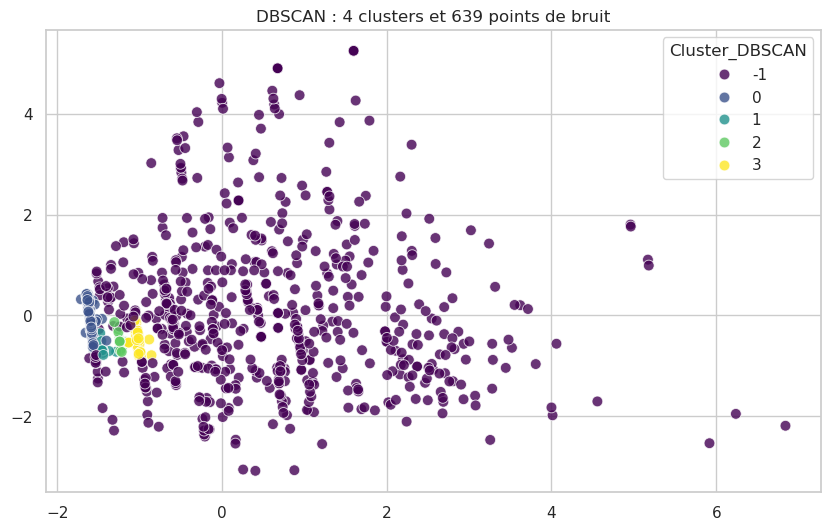

📊 Silhouette Score (hors bruit) : 0.650


In [43]:
from sklearn.cluster import DBSCAN

# À ajuster selon le graphique ci-dessus (la valeur du 'genou')
eps_choisi = 0.4

dbscan = DBSCAN(eps=eps_choisi, min_samples=min_pts)
db_clusters = dbscan.fit_predict(X_scaled)

# Ajout au DataFrame
df_clean['Cluster_DBSCAN'] = db_clusters

# 1. Statistiques des clusters
n_clusters_ = len(set(db_clusters)) - (1 if -1 in db_clusters else 0)
n_noise_ = list(db_clusters).count(-1)

print(f"✅ DBSCAN terminé")
print(f"🔹 Nombre de clusters trouvés : {n_clusters_}")
print(f"🔹 Nombre de points de bruit (outliers) : {n_noise_}")

# 2. Visualisation PCA
plt.figure(figsize=(10, 6))
# On utilise une palette qui distingue bien le bruit (souvent en noir ou gris)
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1], 
    hue=df_clean['Cluster_DBSCAN'], palette='viridis', s=60, alpha=0.8
)
plt.title(f"DBSCAN : {n_clusters_} clusters et {n_noise_} points de bruit")
plt.show()

# Vérification du score de silhouette (exclure le bruit -1)
mask = db_clusters != -1
if len(set(db_clusters[mask])) > 1:
    score_db = silhouette_score(X_scaled[mask], db_clusters[mask])
    print(f"📊 Silhouette Score (hors bruit) : {score_db:.3f}")
else:
    print("⚠️ Pas assez de clusters pour calculer la silhouette.")

📊 TABLEAU COMPARATIF FINAL :


,K Final,Silhouette,Calinski-Harabasz,Note
Algorithme,,,,
K-Means,4,0.300,211.538,Meilleur pour clusters sphériques
CAH,3,0.408,38.206,Idéal pour structure hiérarchique
DBSCAN,4,0.650,786.768,Gère le bruit (639 points)


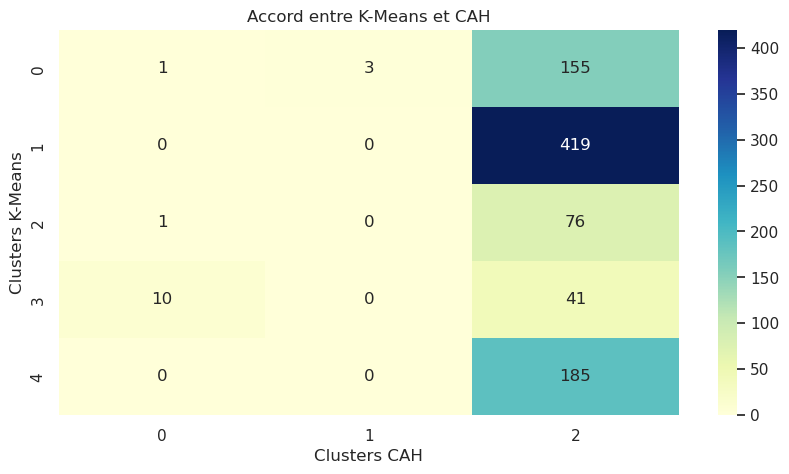

🚀 MODÈLE RECOMMANDÉ : DBSCAN
Justification : Présente la meilleure cohésion interne (Silhouette Score élevé).


In [45]:
# =========================================================
# 1. TABLEAU COMPARATIF DES PERFORMANCES
# =========================================================
from sklearn.metrics import silhouette_score, calinski_harabasz_score

# Calcul des scores pour chaque algo (en excluant le bruit pour DBSCAN)
results = []

# K-Means
results.append({
    'Algorithme': 'K-Means',
    'K Final': k_final,
    'Silhouette': silhouette_score(X_scaled, df_clean['Cluster_KMeans']),
    'Calinski-Harabasz': calinski_harabasz_score(X_scaled, df_clean['Cluster_KMeans']),
    'Note': 'Meilleur pour clusters sphériques'
})

# CAH
results.append({
    'Algorithme': 'CAH',
    'K Final': k_cah_final,
    'Silhouette': silhouette_score(X_scaled, df_clean['Cluster_CAH']),
    'Calinski-Harabasz': calinski_harabasz_score(X_scaled, df_clean['Cluster_CAH']),
    'Note': 'Idéal pour structure hiérarchique'
})

# DBSCAN (uniquement si au moins 2 clusters trouvés hors bruit)
mask = df_clean['Cluster_DBSCAN'] != -1
if len(set(df_clean.loc[mask, 'Cluster_DBSCAN'])) > 1:
    results.append({
        'Algorithme': 'DBSCAN',
        'K Final': len(set(df_clean.loc[mask, 'Cluster_DBSCAN'])),
        'Silhouette': silhouette_score(X_scaled[mask], df_clean.loc[mask, 'Cluster_DBSCAN']),
        'Calinski-Harabasz': calinski_harabasz_score(X_scaled[mask], df_clean.loc[mask, 'Cluster_DBSCAN']),
        'Note': f'Gère le bruit ({n_noise_} points)'
    })

df_comparaison = pd.DataFrame(results).set_index('Algorithme')
print("📊 TABLEAU COMPARATIF FINAL :")
display(df_comparaison.round(3))

# =========================================================
# 2. SYNTHÈSE VISUELLE (Crosstab)
# =========================================================
plt.figure(figsize=(10, 5))
sns.heatmap(pd.crosstab(df_clean['Cluster_KMeans'], df_clean['Cluster_CAH']), 
            annot=True, fmt='d', cmap='YlGnBu')
plt.title("Accord entre K-Means et CAH")
plt.ylabel("Clusters K-Means")
plt.xlabel("Clusters CAH")
plt.show()

# =========================================================
# 3. RECOMMANDATION FINALE
# =========================================================
best_algo = df_comparaison['Silhouette'].idxmax()
print(f"🚀 MODÈLE RECOMMANDÉ : {best_algo.upper()}")
print(f"Justification : Présente la meilleure cohésion interne (Silhouette Score élevé).")